## Sleep & Lifestyle Dataset Kaggle

- I used this video as a guide: https://www.youtube.com/watch?v=xi0vhXFPegw
- Here's the dataset I imported: https://www.kaggle.com/datasets/ayeshaimran1619/sleep-and-lifestyle-study

In this exercise I'm going to:
- import and read the data
- understand the data
- do data preparation
- feature understanding
- feature relationships

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
sl_data = pd.read_csv("C:/Users/Bobo/Downloads/Sleep_health_and_lifestyle_dataset.csv")

In [82]:
sl_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [83]:
sl_data.shape

(374, 13)

In [84]:
sl_data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

#### Example of Modifying our dataset (dropping columns)

Let's say we decided we don't want to use all of these columns now and we're only interested in a few of them. We'll create a new (sub-dataset), which will only include the necessary ones

In [85]:
sl_data_short = sl_data[['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       #'Quality of Sleep', 
         'Physical Activity Level', 
         'Stress Level',
       'BMI Category' #'Blood Pressure', 'Heart Rate', 'Daily Steps',
       #'Sleep Disorder'
        ]]

We see that we still have 374 rows but this time we have only 8 columns (the ones we want to use further in our analysis)

In [86]:
sl_data_short.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
dtype: object

Everything seems pretty normal here in terms of data formats so we're going to proceed with another task.

## Renaming columns
Let's say we're not happy with the labels of some of our columns

In [87]:
sl_data_short.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category
0,1,Male,27,Software Engineer,6.1,42,6,Overweight
1,2,Male,28,Doctor,6.2,60,8,Normal
2,3,Male,28,Doctor,6.2,60,8,Normal
3,4,Male,28,Sales Representative,5.9,30,8,Obese
4,5,Male,28,Sales Representative,5.9,30,8,Obese


In [88]:
# Let's say we don't like the "Sleep Duration" column name:
sl_data_short.columns # we use this column command once again just to see what the names of our columns looked like exactly

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Physical Activity Level', 'Stress Level', 'BMI Category'],
      dtype='object')

In [89]:
sl_data_short = sl_data_short.rename(columns={'Sleep Duration': 'Sleep_Dur',
                     'Physical Activity Level': 'Activity_Level'})

In [90]:
sl_data_short

,Person ID,Gender,Age,Occupation,Sleep_Dur,Activity_Level,Stress Level,BMI Category
0,1,Male,27,Software Engineer,6.1,42,6,Overweight
1,2,Male,28,Doctor,6.2,60,8,Normal
2,3,Male,28,Doctor,6.2,60,8,Normal
3,4,Male,28,Sales Representative,5.9,30,8,Obese
4,5,Male,28,Sales Representative,5.9,30,8,Obese
...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,75,3,Overweight
370,371,Female,59,Nurse,8.0,75,3,Overweight
371,372,Female,59,Nurse,8.1,75,3,Overweight
372,373,Female,59,Nurse,8.1,75,3,Overweight


## Checking for Null Values

Now, I will be checking if there are any null values in the dataset:

In [91]:
sl_data_short.isna().sum()

Person ID         0
Gender            0
Age               0
Occupation        0
Sleep_Dur         0
Activity_Level    0
Stress Level      0
BMI Category      0
dtype: int64

## Checking for Duplicates

In [92]:
sl_data_short.duplicated().sum()

np.int64(0)

#### Checking an example duplicate
We're going to check for all the rows where people have "Software Engineer" as an occupation

In [93]:
sl_data_short.query('Occupation == "Software Engineer"')

,Person ID,Gender,Age,Occupation,Sleep_Dur,Activity_Level,Stress Level,BMI Category
0,1,Male,27,Software Engineer,6.1,42,6,Overweight
5,6,Male,28,Software Engineer,5.9,30,8,Obese
84,85,Male,35,Software Engineer,7.5,60,5,Normal Weight
92,93,Male,35,Software Engineer,7.5,60,5,Normal Weight


### Creation of a new dataframe
For the purposes of this example, I'm going to create a new dataframe that will only include columns that we're intereted in

In [94]:
sl_data_short.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep_Dur',
       'Activity_Level', 'Stress Level', 'BMI Category'],
      dtype='object')

I will check for all the duplicate rows we have in our current dataset and the sum of the duplicate rows

In [95]:
sl_data_short.duplicated(subset=['Gender', 'Age', 'Occupation', 'Sleep_Dur','Activity_Level', 'Stress Level', 'BMI Category']).sum()

np.int64(265)

So, now let's take a look at all the other ones that do not have duplicates by using "~" in our code and save it as our new dataframe:

In [96]:
sl_data_short = sl_data_short.loc[~sl_data_short.duplicated(subset=['Gender', 'Age', 'Occupation', 'Sleep_Dur','Activity_Level', 'Stress Level', 'BMI Category'])]
sl_data_short

,Person ID,Gender,Age,Occupation,Sleep_Dur,Activity_Level,Stress Level,BMI Category
0,1,Male,27,Software Engineer,6.1,42,6,Overweight
1,2,Male,28,Doctor,6.2,60,8,Normal
3,4,Male,28,Sales Representative,5.9,30,8,Obese
5,6,Male,28,Software Engineer,5.9,30,8,Obese
6,7,Male,29,Teacher,6.3,40,7,Obese
...,...,...,...,...,...,...,...,...
344,345,Female,57,Nurse,8.2,75,3,Overweight
352,353,Female,58,Nurse,8.0,75,3,Overweight
358,359,Female,59,Nurse,8.0,75,3,Overweight
359,360,Female,59,Nurse,8.1,75,3,Overweight


In [97]:
sl_data_short.loc[~sl_data_short.duplicated(subset=['Gender', 'Age', 'Occupation', 'Sleep_Dur','Activity_Level', 'Stress Level', 'BMI Category'])] \
    .reset_index(drop=True)

,Person ID,Gender,Age,Occupation,Sleep_Dur,Activity_Level,Stress Level,BMI Category
0,1,Male,27,Software Engineer,6.1,42,6,Overweight
1,2,Male,28,Doctor,6.2,60,8,Normal
2,4,Male,28,Sales Representative,5.9,30,8,Obese
3,6,Male,28,Software Engineer,5.9,30,8,Obese
4,7,Male,29,Teacher,6.3,40,7,Obese
...,...,...,...,...,...,...,...,...
104,345,Female,57,Nurse,8.2,75,3,Overweight
105,353,Female,58,Nurse,8.0,75,3,Overweight
106,359,Female,59,Nurse,8.0,75,3,Overweight
107,360,Female,59,Nurse,8.1,75,3,Overweight


In [98]:
sl_data_short.shape

(109, 8)

## Feature Understanding
### Plotting Feature Distributions
- Histogram
- KDE
- Boxplot

We're going to see the number of unique values that occur in this dataset in terms of occupation:

In [99]:
sl_data_short['Occupation'].value_counts()

Occupation
Doctor                  21
Nurse                   21
Engineer                19
Teacher                 12
Lawyer                  12
Accountant              10
Salesperson              7
Software Engineer        3
Scientist                2
Sales Representative     1
Manager                  1
Name: count, dtype: int64

## Creating a Bar Chart

Text(0, 0.5, 'Occupation')

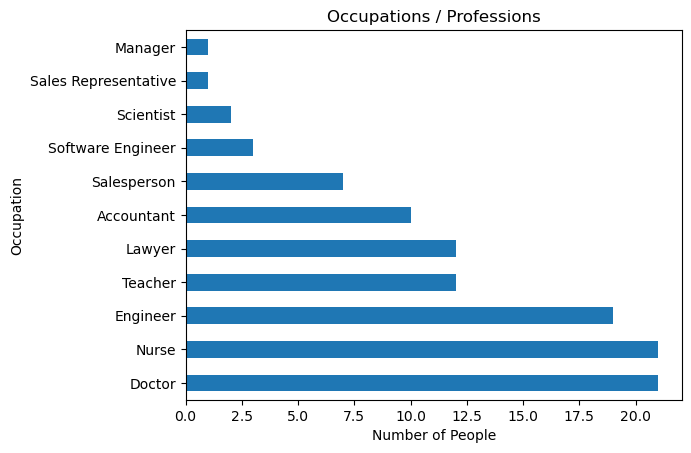

In [107]:
ax = sl_data_short['Occupation'].value_counts() \
    .plot(kind='barh', title = 'Occupations / Professions')

ax.set_xlabel('Number of People')
ax.set_ylabel('Occupation')

## Let's Get an Idea of the Distribution of the Age using a Histogram

Text(0, 0.5, 'Num of People')

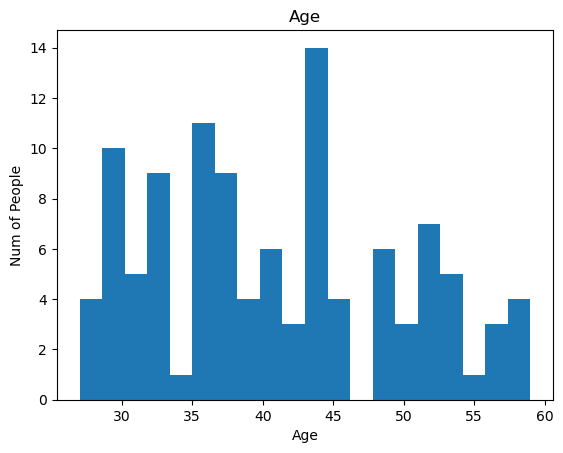

In [114]:
age_distribution = sl_data_short['Age'].plot(kind='hist', 
                                             bins=20, 
                                             title='Age')

age_distribution.set_xlabel('Age')
age_distribution.set_ylabel('Num of People')

## Let's Get an Idea of the Distribution of the Age using a KDE

Text(0, 0.5, 'Num of People')

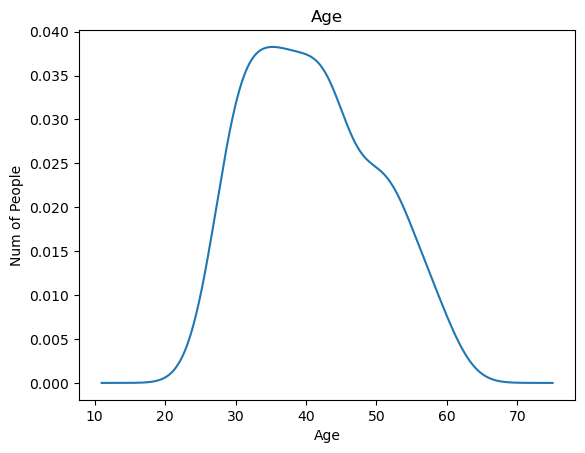

In [115]:
age_distribution = sl_data_short['Age'].plot(kind='kde',  
                                             title='Age')

age_distribution.set_xlabel('Age')
age_distribution.set_ylabel('Num of People')

### Feature Relationships
- Scatterplot
- Heatmap Correlation
- Pairplot
- Groupby Comparisons